# Calibration

Convergence only tells us the sampler explored the posterior, not whether the
uncertainty it reports is honest. We use three lenses:
1. The probability integral transform (PIT) and;
2. quantile coverage check the posterior predictive against held-out data.
3. Simulation-based calibration (SBC) checks the inference itself across many datasets drawn from the prior.

## Load the calibration inputs

Results saved the posterior draws, the training and held-out test sets and the
SBC ranks. The predictive checks are computed here from the draws, nothing is
refitted. Run `01_results.ipynb` first if this cell cannot find them.

In [1]:
import sys
from pathlib import Path

# The project root is the directory holding src/toynuts. From it we put the
# package on the path (no install needed) and fix one run directory the three
# notebooks share: Results writes it, Diagnostics and Calibration read it.
PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "toynuts").is_dir()),
    Path.cwd(),
)
if not any((Path(p) / "toynuts").is_dir() for p in sys.path):
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
RUN_DIR = PROJECT_ROOT / "outputs" / "notebook_run"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from toynuts import plotting as P
from toynuts.io import read_run
from toynuts.calibration import (
    pit_rb, loo_pit, coverage_from_pit, loo_elpd, crps_mixture,
    stratified_pit, ecdf_simultaneous_band, empirical_cdf,
)

plt.rcParams["figure.dpi"] = 110

if not RUN_DIR.exists():
    raise FileNotFoundError(f"no saved run at {RUN_DIR}; run 01_results.ipynb first")
draws, stats, run_config = read_run(RUN_DIR)
post = draws[["beta_0", "beta_1", "sigma"]].to_numpy()
train = pd.read_parquet(RUN_DIR / "train_set.parquet")
test = pd.read_parquet(RUN_DIR / "test_set.parquet")
x, y = train["x"].to_numpy(), train["y"].to_numpy()
X = np.column_stack([np.ones_like(x), x])
x_test, y_test = test["x_test"].to_numpy(), test["y_test"].to_numpy()
X_test = np.column_stack([np.ones_like(x_test), x_test])
ranks = pd.read_parquet(RUN_DIR / "sbc_ranks.parquet")[["beta_0", "beta_1", "sigma"]].to_numpy()
meta = pd.read_parquet(RUN_DIR / "sbc_meta.parquet").iloc[0]
n_sims, L = int(meta["n_sims"]), int(meta["n_thinned"])
print(f"posterior draws {post.shape[0]}, train {y.size}, test {y_test.size}, SBC sims {n_sims}")

posterior draws 8000, train 80, test 400, SBC sims 400


## Two kinds of PIT: held-out and leave-one-out

The probability integral transform asks where each observed $y$ falls in its
predictive distribution, $u_i = P(\tilde y \le y_i)$. If the predictive is
calibrated these values are Uniform(0, 1). There are two honest ways to compute
it.

**Held-out PIT** uses a separate test set the sampler never saw. Each point is
out-of-sample by construction, so no correction is needed.

**LOO-PIT** uses the training data, but evaluating the predictive on a point that
helped fit it is over-optimistic. Leave-one-out asks instead what the predictive
would say with that point removed, $u_i = P(\tilde y \le y_i \mid y_{-i})$.
Refitting once per point is avoided with Pareto-smoothed importance sampling:
reweight the single fit by $1 / p(y_i \mid \theta_s)$, smooth the weights and
read the Pareto $\hat k$ to know when they are reliable.

Both are Rao-Blackwellised: the per-draw Gaussian CDF is averaged over the draws,
never sampling $\tilde y$. Both read the same shapes, a U for over-confidence, an
inverted U for over-dispersion and a slope for bias.

## Held-out PIT

The Rao-Blackwellised predictive CDF at each held-out point, averaged over the
posterior draws. The histogram should be flat and the ECDF-minus-uniform curve
should stay inside the 95% simultaneous band, which controls the error across the
whole curve rather than point by point.

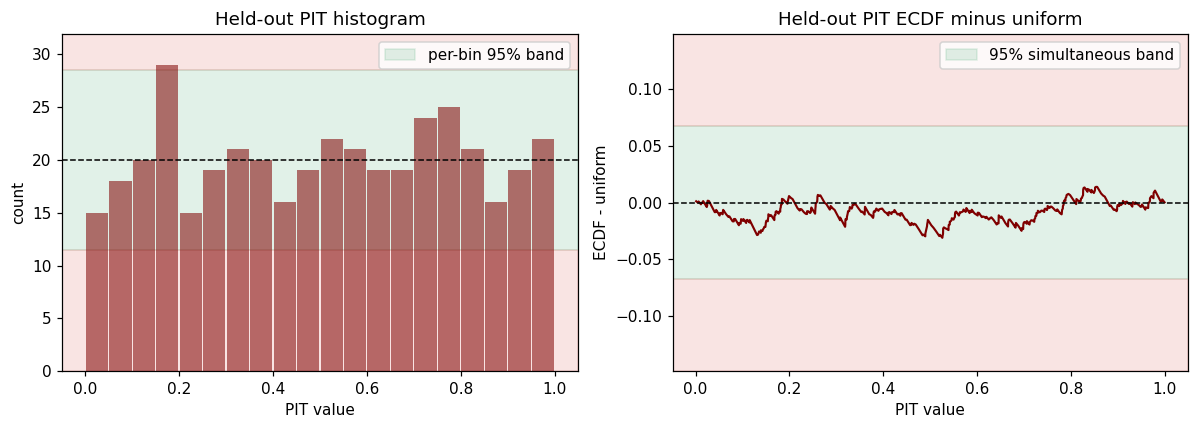

held-out PIT mean 0.510 (uniform 0.5), KS 0.031


In [2]:
pit = pit_rb(y_test, X_test, post)
xe, fe = empirical_cdf(pit)
m = pit.size
band = ecdf_simultaneous_band(m, prob=0.95, rng=np.random.default_rng(7))

nbins = 20
counts, edges = np.histogram(pit, bins=nbins, range=(0, 1))
centres = 0.5 * (edges[:-1] + edges[1:])
expected = m / nbins
bin_band = 1.96 * np.sqrt(m * (1 / nbins) * (1 - 1 / nbins))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(centres, counts, width=0.95 / nbins, color=P.POSTERIOR_DEEP, alpha=0.55)
P.traffic_band(axes[0], expected - bin_band, expected + bin_band,
               ylim=(0, max(counts.max(), expected + bin_band) * 1.1), label="per-bin 95% band")
axes[0].axhline(expected, color="k", ls="--", lw=1)
axes[0].set(title="Held-out PIT histogram", xlabel="PIT value", ylabel="count")
axes[0].legend()
axes[1].plot(xe, fe - xe, color=P.POSTERIOR_DEEP, lw=1.4)
P.traffic_band(axes[1], -band, band, label="95% simultaneous band")
axes[1].axhline(0.0, color="k", ls="--", lw=1)
axes[1].set(title="Held-out PIT ECDF minus uniform", xlabel="PIT value", ylabel="ECDF - uniform")
axes[1].legend()
fig.tight_layout()
plt.show()
print(f"held-out PIT mean {pit.mean():.3f} (uniform 0.5), KS {np.max(np.abs(fe - xe)):.3f}")

## LOO-PIT

The in-sample check on the training data, corrected by Pareto-smoothed importance
sampling. The Pareto $\hat k$ stays well below 0.7, so the leave-one-out weights
are reliable.

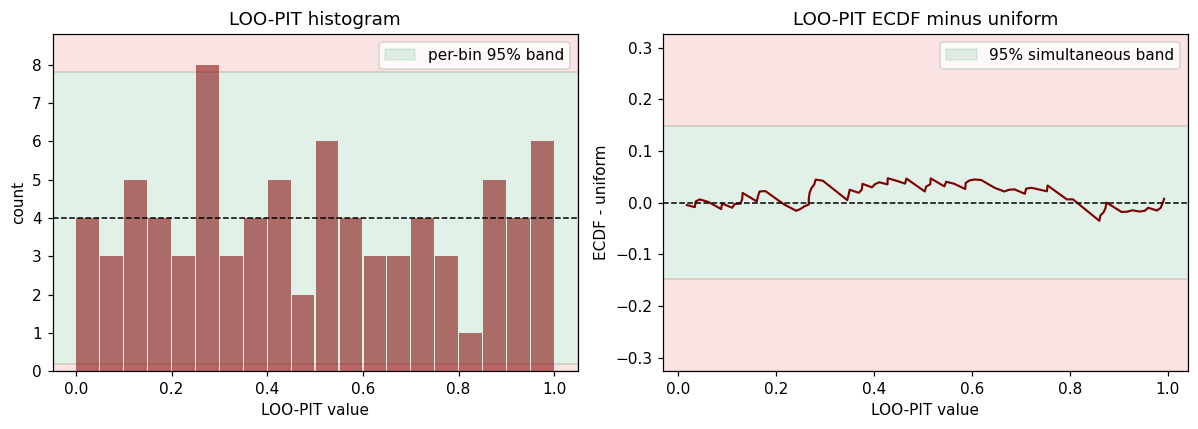

LOO-PIT mean 0.492, max Pareto k 0.21 (reliable below 0.7)


In [3]:
loo, khat = loo_pit(y, X, post)
xe, fe = empirical_cdf(loo)
m = loo.size
band = ecdf_simultaneous_band(m, prob=0.95, rng=np.random.default_rng(8))

nbins = 20
counts, edges = np.histogram(loo, bins=nbins, range=(0, 1))
centres = 0.5 * (edges[:-1] + edges[1:])
expected = m / nbins
bin_band = 1.96 * np.sqrt(m * (1 / nbins) * (1 - 1 / nbins))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(centres, counts, width=0.95 / nbins, color=P.POSTERIOR_DEEP, alpha=0.55)
P.traffic_band(axes[0], expected - bin_band, expected + bin_band,
               ylim=(0, max(counts.max(), expected + bin_band) * 1.1), label="per-bin 95% band")
axes[0].axhline(expected, color="k", ls="--", lw=1)
axes[0].set(title="LOO-PIT histogram", xlabel="LOO-PIT value", ylabel="count")
axes[0].legend()
axes[1].plot(xe, fe - xe, color=P.POSTERIOR_DEEP, lw=1.4)
P.traffic_band(axes[1], -band, band, label="95% simultaneous band")
axes[1].axhline(0.0, color="k", ls="--", lw=1)
axes[1].set(title="LOO-PIT ECDF minus uniform", xlabel="LOO-PIT value", ylabel="ECDF - uniform")
axes[1].legend()
fig.tight_layout()
plt.show()
print(f"LOO-PIT mean {loo.mean():.3f}, max Pareto k {np.nanmax(khat):.2f} (reliable below 0.7)")

## Stratified PIT

Marginal PIT can be uniform while the model is miscalibrated within regions,
because opposing errors cancel in aggregate. Splitting the held-out PIT by where
the point sits in $x$ and checking each band localises any structured failure.

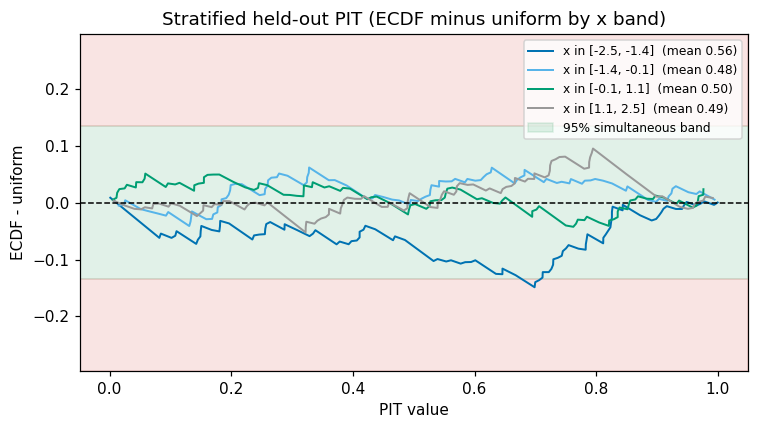

In [4]:
nbin = 4
edges = np.quantile(x_test, np.linspace(0, 1, nbin + 1))
strata = np.clip(np.digitize(x_test, edges[1:-1]), 0, nbin - 1)
groups = stratified_pit(pit, strata)
# Strata are near-equal by quantile construction; size one conservative 95%
# simultaneous band to the smallest stratum and share it across the bands.
band = ecdf_simultaneous_band(min(g.size for g in groups.values()), prob=0.95,
                              rng=np.random.default_rng(11))

fig, ax = plt.subplots(figsize=(7, 4))
for s in range(nbin):
    xe_s, fe_s = empirical_cdf(groups[s])
    lbl = f"x in [{edges[s]:.1f}, {edges[s + 1]:.1f}]  (mean {groups[s].mean():.2f})"
    ax.plot(xe_s, fe_s - xe_s, lw=1.3, color=P.param_colour(s), label=lbl)
P.traffic_band(ax, -band, band, label="95% simultaneous band")
ax.axhline(0.0, color="k", ls="--", lw=1)
ax.set(title="Stratified held-out PIT (ECDF minus uniform by x band)",
       xlabel="PIT value", ylabel="ECDF - uniform")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Quantile coverage

The same idea read as a calibration curve, now inverting the same averaged
predictive CDF. A central $q$ interval contains $y_i$ when its PIT lies in
$[(1 - q)/2, (1 + q)/2]$, so coverage reads straight off the held-out PIT.
Calibrated coverage tracks the diagonal.

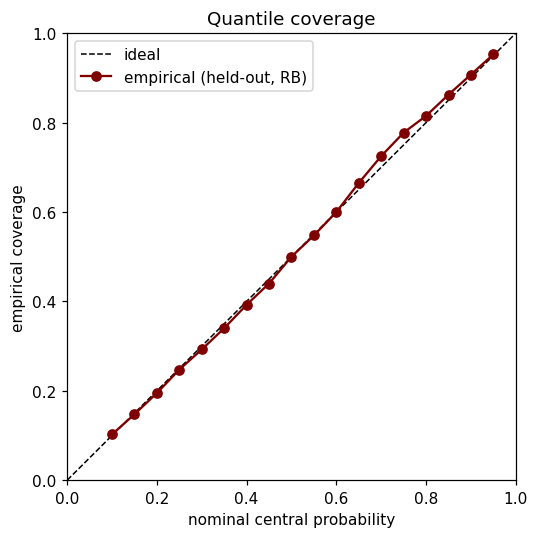

In [5]:
levels = np.linspace(0.1, 0.95, 18)
cover = coverage_from_pit(pit, levels)   # pit is the held-out Rao-Blackwellised PIT

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="ideal")
ax.plot(levels, cover, "o-", color=P.POSTERIOR_DEEP, label="empirical (held-out, RB)")
ax.set(xlabel="nominal central probability", ylabel="empirical coverage",
       title="Quantile coverage", xlim=(0, 1), ylim=(0, 1))
ax.legend()
fig.tight_layout()
plt.show()

## Proper scores: elpd and CRPS

Calibration is necessary but not sufficient; among calibrated models the sharpest
is preferred. The log-score is the expected log pointwise predictive density by
PSIS-LOO, reported with its standard error, the effective number of parameters
$p_{loo}$ and the per-point Pareto $\hat k$. CRPS is a distance-based score on the
held-out set, lower being sharper.

elpd_loo -115.4 +/- 6.0, p_loo 2.77 (parameters: 3)
mean CRPS on the held-out set 0.560


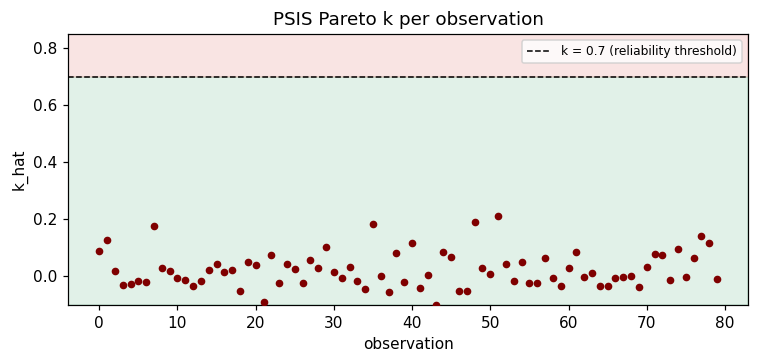

In [6]:
elpd = loo_elpd(y, X, post)
crps = crps_mixture(y_test, X_test, post)
print(f"elpd_loo {float(elpd['elpd']):.1f} +/- {float(elpd['se']):.1f}, "
      f"p_loo {float(elpd['p_loo']):.2f} (parameters: 3)")
print(f"mean CRPS on the held-out set {crps.mean():.3f}")

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.scatter(np.arange(y.size), elpd["k_hat"], s=16, color=P.POSTERIOR_DEEP, zorder=3)
ax.set_ylim(min(-0.05, float(np.nanmin(elpd["k_hat"]))), 0.85)
# Green below the 0.7 reliability line (good), red above (unreliable weights).
P.traffic_threshold(ax, 0.7, good_below=True)
ax.axhline(0.7, color="k", ls="--", lw=1, label="k = 0.7 (reliability threshold)")
ax.set(title="PSIS Pareto k per observation", xlabel="observation", ylabel="k_hat")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Simulation-based calibration (SBC)

SBC tests the inference itself rather than one dataset. A cheap precursor is
parameter recovery: simulate one dataset from a known parameter set, fit, and
confirm the truth sits in the bulk of the posterior, which the Results notebook's
quantitative check already does. SBC generalises it: draw a parameter set from
the prior, simulate data, refit, and record the rank of each true value among its
posterior draws. Averaged over many datasets the ranks must be uniform when the
sampler targets the correct posterior. Read here as the ECDF minus uniform with a
95% simultaneous band, the curve stays inside the band under a calibrated
sampler; a lean to the edges would mean posteriors too narrow, a central hump too
wide.

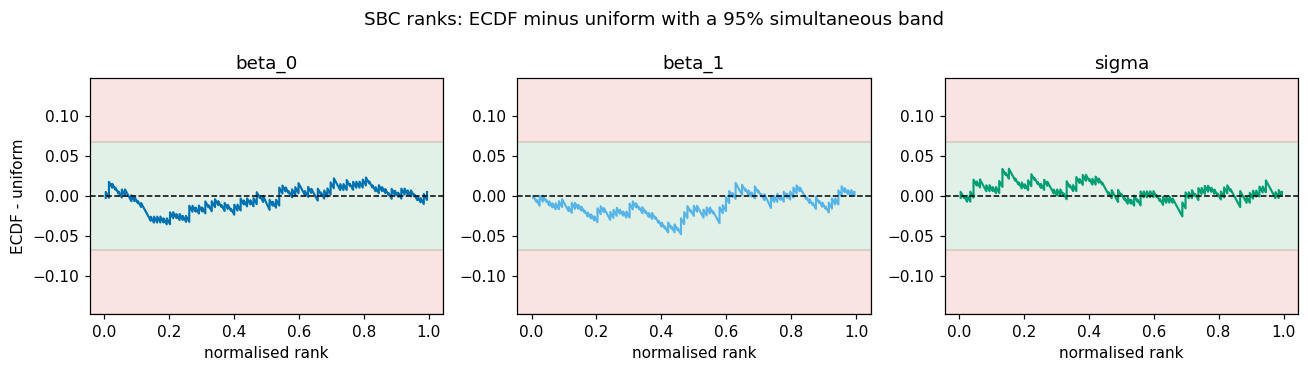

In [7]:
names = ["beta_0", "beta_1", "sigma"]
band = ecdf_simultaneous_band(n_sims, prob=0.95, rng=np.random.default_rng(9))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for k, ax in enumerate(axes):
    u = (ranks[:, k] + 0.5) / (L + 1)            # map ranks in 0..L to (0, 1)
    xe, fe = empirical_cdf(u)
    ax.plot(xe, fe - xe, color=P.param_colour(k), lw=1.4)
    P.traffic_band(ax, -band, band, ylim=(-band * 2.2, band * 2.2))
    ax.axhline(0.0, color="k", ls="--", lw=1)
    ax.set(title=names[k], xlabel="normalised rank")
axes[0].set_ylabel("ECDF - uniform")
fig.suptitle("SBC ranks: ECDF minus uniform with a 95% simultaneous band")
fig.tight_layout()
plt.show()

## Verdict

The held-out PIT and LOO-PIT, coverage, Pareto $\hat k$ and SBC checks agree:
the posterior predictive is calibrated out-of-sample and in-sample, the
importance-sampling LOO is reliable, and there is no sign the sampler's
prior-to-posterior map is biased. The uncertainty reported in the Results notebook is
trustworthy, not just the point estimates.